# Import libraries

In [70]:
# Data manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Decomposition
from sklearn.decomposition import PCA

# Manifold 
from sklearn.manifold import TSNE

# umap
import umap

# time
import time

# Load the dataset

In [73]:
# The MNIST is a database of handwritten digits 
X, y_raw = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y_raw.astype(np.uint8)

# Explore the dataset

In [75]:
# (no_of_row, n0_of_feature)
X.shape

(70000, 784)

In [76]:
# no_pf_label
y.shape

(70000,)

# Display one digit

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

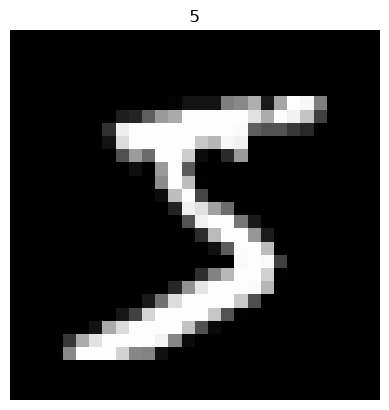

In [78]:
plt.imshow(
    X[0].reshape(28,28),
    cmap="gray"
)

plt.title(y[0])

plt.axis("off")

# Display multiple digits

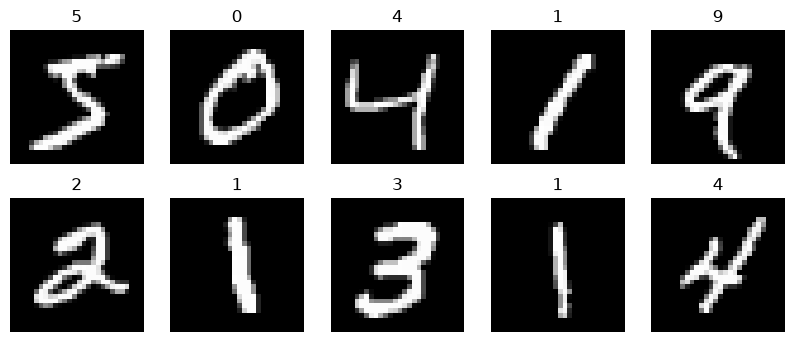

In [80]:
# Display multiple digits
fig, axes = plt.subplots(2,5,figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28,28), cmap="gray")
    ax.set_title(y[i])
    ax.axis("off")

# Feature scaling

In [81]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Principal Component Analysis (PCA)

In [82]:
start = time.time()
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
end = time.time()
pca_time = end -start

# Variance explanation

Variance represents how much the pixels in your dataset change, differ, or "vary" from one image to another.

In [50]:
# Explained variance
variance = pca.explained_variance_ratio_

In [51]:
# Comulative variance
# The goal of calculating cumulative variance is to find the cutoff point. For example, the first 30
#  ]components capture 95% of the total variance.
comulative = np.cumsum(variance)

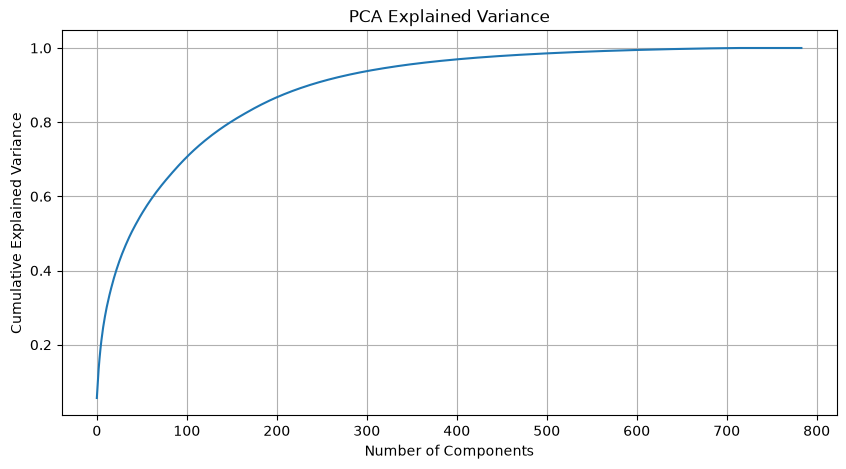

In [83]:
plt.figure(figsize=(10,5))
plt.plot(comulative)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

The number of components are around 400 for gaining 95% of the variance

# PCA in 3 dimensions

In [84]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

Text(0.5, 0.92, '3D PCA')

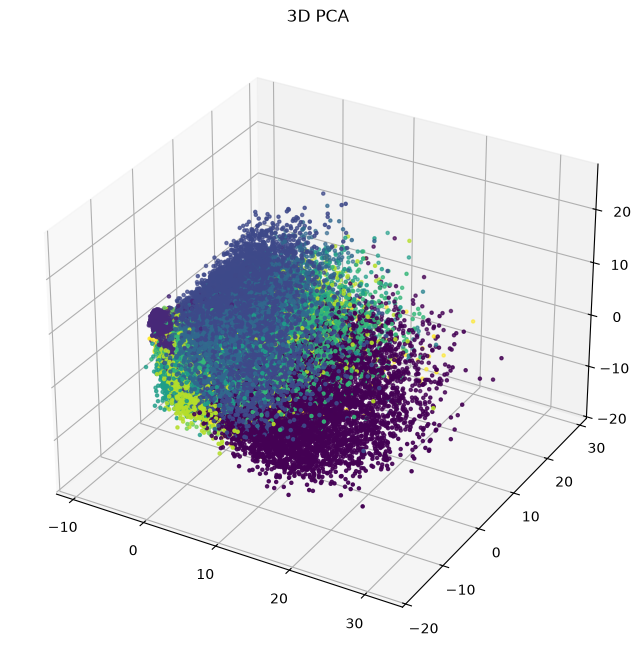

In [85]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    projection="3d"
)

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=y,
    s=5
)

plt.title("3D PCA")

# t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a ML algorithm used to visualize high-dimensional data in a 2D or 3D scatter plot. While PCA focuses on preserving the overall global structure and maximum variance, t-SNE focuses on preserving local structures—meaning it ensures that data points that are close together in high-dimensional space stay close together in the visualization.

In [87]:
# Because t-SNE is computationally expensive, we use a subset (i.e., first 5000 data).
X_small = X_scaled[:5000]
y_small = y[:5000]

In [88]:
start = time.time()

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_small)
end = time.time()
tsne_time = end-start
print(end-start)

8.845408916473389


Text(0.5, 1.0, 't-SNE')

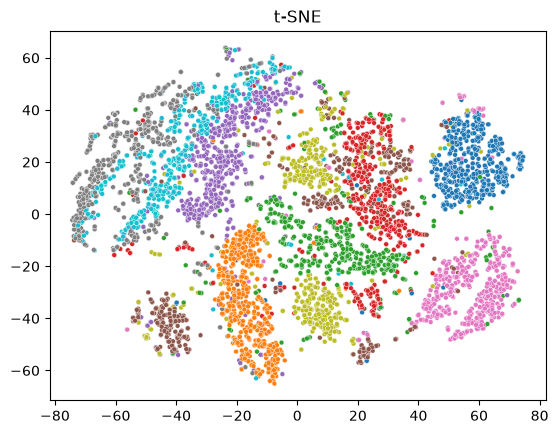

In [89]:
fig = plt.Figure(figsize=(10,8))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y_small,
    palette="tab10",
    legend=False,
    s=12
)

plt.title("t-SNE")

# UMAP

UMAP (Uniform Manifold Approximation and Projection) is a modern machine learning algorithm used for dimension reduction and 2D/3D visualization.

In [96]:
start = time.time()
reducer = umap.UMAP(
    random_state=42
)

X_umap = reducer.fit_transform(
    X_small
)
end = time.time()
umap_time = end - start

c:\ML-exploration\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'UMAP')

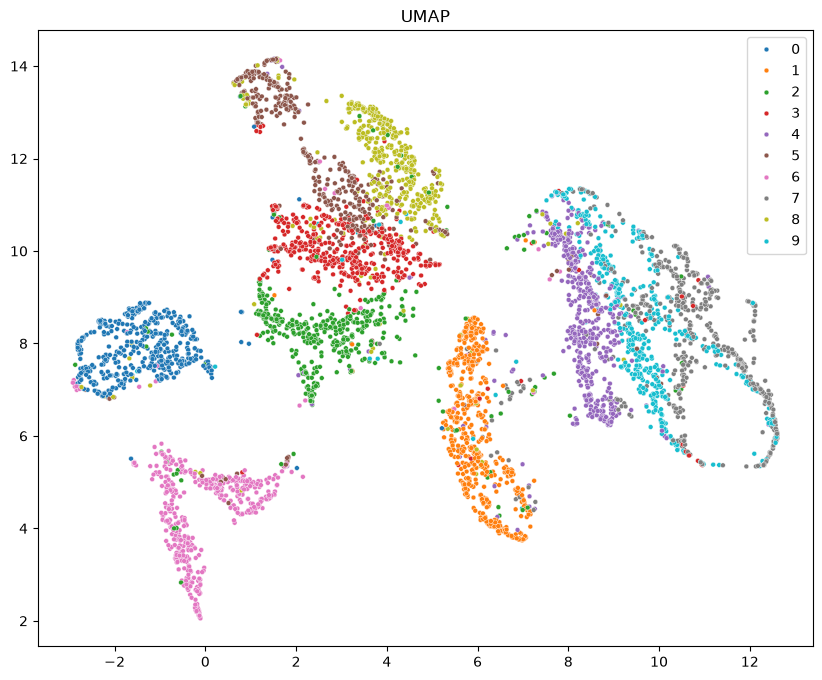

In [97]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=y_small,
    palette="tab10",
    legend=True,
    s=12
)

plt.title("UMAP")

# Runtime comparison

In [98]:
comparison = pd.DataFrame({

    "Method":[
        "PCA",
        "t-SNE",
        "UMAP"
    ],

    "Runtime (seconds)":[
        pca_time,
        tsne_time,
        umap_time
    ]

})

comparison

,Method,Runtime (seconds)
0,PCA,2.593740
1,t-SNE,8.845409
2,UMAP,4.556896


UMAP is generally faster than t-SNE while preserving both local and some global structure.

# Algorithm comparison

| Algorithm | Type| Strengths  | Weaknesses                                |
| --------- | ----| ------------------------------------------------------ | ---------------------------------- |
| PCA  | Linear   | Fast, interpretable, preserves global variance         | Cannot model nonlinearrelationships|
| t-SNE| Nonlinear| Excellent visualization of local clusters              | Slow, not suitable for transforming new data |
| UMAP | Nonlinear| Fast, scalable, preserves local and some global structure | Sensitive to parameter choices            |
